In [ ]:
#Authenticate and connect to BigQuery

from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery

project_id = 'fleet-bus-501308-f1'
client = bigquery.Client(project=project_id)

In [ ]:
#Query the data into dataframe

query = """
SELECT *
FROM `olist_data.customer_segments`
"""

df = client.query(query).to_dataframe()
df.head()

,customer_unique_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_total,customer_segment
0,3c6f8c4f55b17170c918087b2687e2b7,431,1,50.09,1,1,1,3,Lost
1,81fcf63a0d321f011729abaa17f28c47,431,1,49.11,1,1,1,3,Lost
2,722e107e3d0f6ff698392d4bb9488d87,431,1,55.00,1,1,1,3,Lost
3,0cb82f96265f91a6d022ce6a3f62dcb2,431,1,27.76,1,1,1,3,Lost
4,86b7be8e3ba4d83d6a477c729246c277,431,1,44.00,1,1,1,3,Lost


In [ ]:
df.shape

(93357, 9)

In [ ]:
df.describe()

,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_total
count,93357.0,93357.0,93357.000000,93357.0,93357.0,93357.0,93357.0
mean,286.473783,1.03342,165.198772,2.999968,1.033056,2.999968,7.032992
std,152.587935,0.209099,226.314579,1.414225,0.198758,1.414225,2.052861
min,49.0,1.0,9.590000,1.0,1.0,1.0,3.0
25%,163.0,1.0,63.060000,2.0,1.0,2.0,6.0
50%,267.0,1.0,107.780000,3.0,1.0,3.0,7.0
75%,395.0,1.0,182.560000,4.0,1.0,4.0,8.0
max,744.0,15.0,13664.080000,5.0,5.0,5.0,15.0


In [ ]:
df['customer_segment'].value_counts()

,count
customer_segment,
Recent Customers,36141
Needs Attention,25281
Lost,15348
Can't Lose Them,13786
Loyal Customers,1693
At Risk,992
Champions,116


In [ ]:
df.isnull().sum()

,0
customer_unique_id,0
recency_days,0
frequency,0
monetary,0
recency_score,0
frequency_score,0
monetary_score,0
rfm_total,0
customer_segment,0


In [ ]:
df.sort_values('monetary', ascending=False).head(15)

,customer_unique_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_total,customer_segment
68691,0a0a92112bd4c708ca5fde585afaa872,383,1,13664.08,2,1,5,8,Can't Lose Them
70029,da122df9eeddfedc1dc1f5349a1a690c,564,2,7571.63,1,2,5,8,At Risk
90912,763c8b1c9c68a0229c42c9fc6f662b93,94,1,7274.88,5,1,5,11,Recent Customers
54824,dc4802a71eae9be1dd28f5d788ceb526,612,1,6929.31,1,1,5,7,Can't Lose Them
90475,459bef486812aa25204be022145caa62,84,1,6922.21,5,1,5,11,Recent Customers
53236,ff4159b92c40ebe40454e3e6a7c35ed6,511,1,6726.66,1,1,5,7,Can't Lose Them
66968,4007669dec559734d6f53e029e360987,327,1,6081.54,2,1,5,8,Can't Lose Them
53946,eebb5dda148d3893cdaf5b5ca3040ccb,547,1,4764.34,1,1,5,7,Can't Lose Them
91636,48e1ac109decbb87765a3eade6854098,117,1,4681.78,5,1,5,11,Recent Customers
93341,c8460e4251689ba205045f3ea17884a1,70,4,4655.91,5,4,5,14,Champions


In [ ]:
#importing necessary libraries for plotting

import matplotlib.pyplot as plt
import seaborn as sns



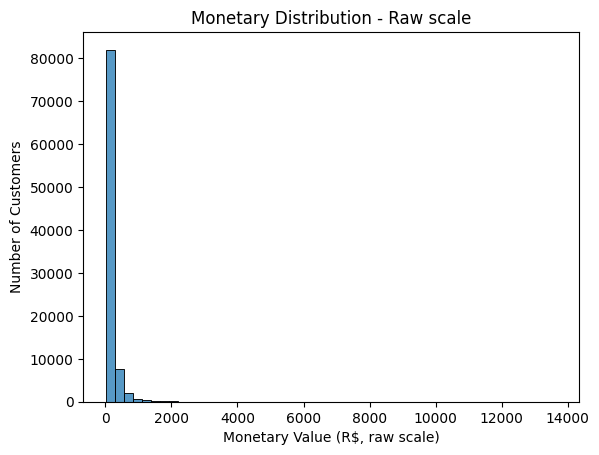

In [ ]:
#Monetary Distribution(Raw Scale)
sns.histplot(df['monetary'], bins=50)
plt.title('Monetary Distribution - Raw scale')
plt.xlabel('Monetary Value (R$, raw scale)')
plt.ylabel('Number of Customers')
plt.show()

### Key Findings
Monetary values are heavily right-skewed on the raw scale, with the
majority of customers spending under R\$500 and a long tail of high-value
outliers extending beyond R\$10,000. The median spend sits at R\$108,
confirming that most customers make modest purchases while a small group
drives disproportionate revenue.

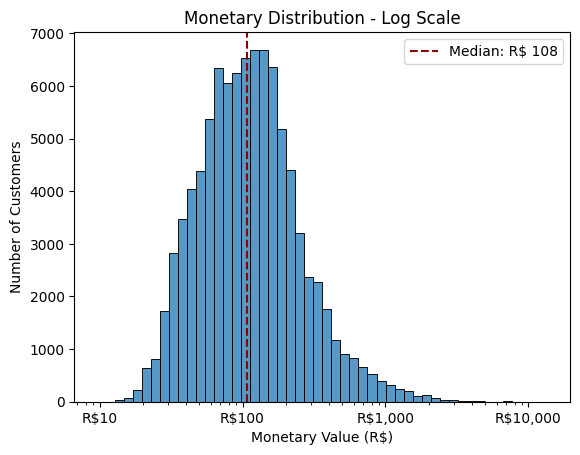

In [ ]:
#Monetary Distribution (Log Scale)
import matplotlib.ticker as mticker

sns.histplot(df['monetary'], bins=50, log_scale=True)
plt.title('Monetary Distribution - Log Scale')
plt.xlabel('Monetary Value (R$)')
plt.ylabel('Number of Customers')
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x):,}'))
plt.axvline(df['monetary'].median(),
            color='darkred',
            linestyle='--',
            linewidth=1.5,
            label=f'Median: R$ {df["monetary"].median():.0f}')
plt.legend()
plt.show()

### Key Findings
Applying a log transformation reveals an approximately normal distribution
peaking between R\$100-R\$200, confirming monetary values follow a
log-normal pattern, the standard distribution for ecommerce spend data.
The median line at R\$108 sits cleanly at the curve's peak, representing the typical customer transaction value.

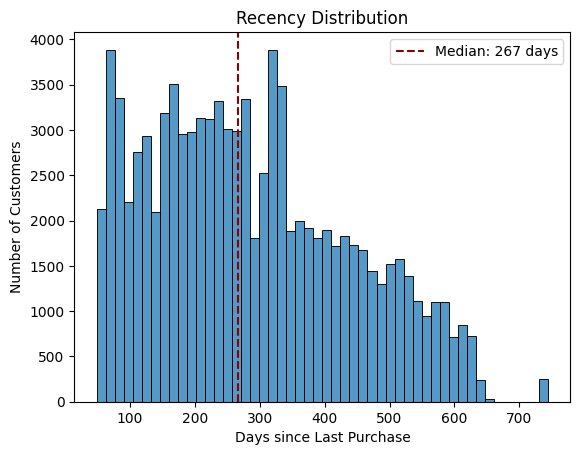

In [ ]:
#Recency Distribution
sns.histplot(df['recency_days'], bins = 50)
plt.title('Recency Distribution')
plt.xlabel('Days since Last Purchase')
plt.ylabel('Number of Customers')

plt.axvline(df['recency_days'].median(),
            color='darkred',
            linestyle='--',
            linewidth=1.5,
            label=f'Median: {df["recency_days"].median():.0f} days')
plt.legend()
plt.show()

###Key Findings
Recency days show a right skewed distribution with a concentration of
recent buyers in the 50-100 day range and a notable secondary peak around
300-350 days, suggesting a seasonal or promotional acquisition event in
Olist's history. The median recency of approximately 260 days indicates
that the typical customer last purchased around 8-9 months before the
dataset cutoff, highlighting the challenge of re engagement across the
broader customer base.

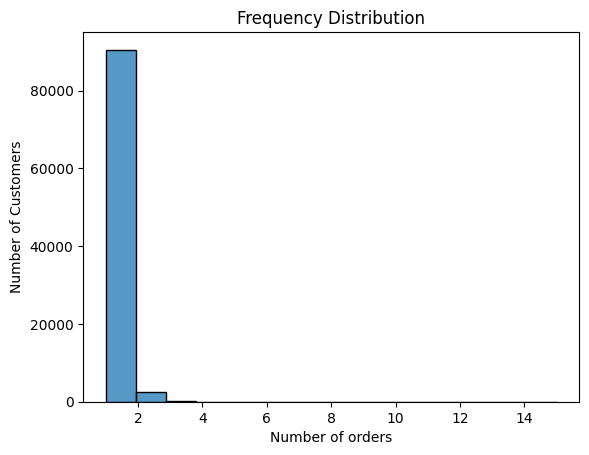

In [ ]:
#Frequency Distribution
sns.histplot(df['frequency'], bins = 15)
plt.title("Frequency Distribution")
plt.xlabel('Number of orders')
plt.ylabel('Number of Customers')
plt.show()

### Key Findings
Over 97% of customers placed exactly one order, confirming that repeat
purchasing is rare in this dataset. This reflects the fledging stage of
Brazilian e-commerce during 2016-2018, where most customers were
first-time online buyers. Due to this near-zero variance in frequency,
NTILE-based scoring was replaced with rule-based thresholds to avoid
meaningless equal-bucket splits.

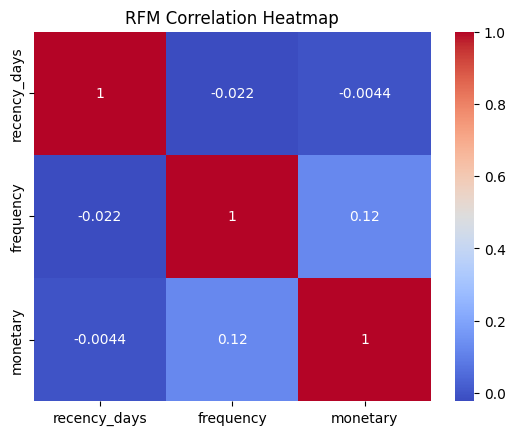

In [ ]:
#Correlation Heatmap
corr = df[['recency_days', 'frequency', 'monetary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('RFM Correlation Heatmap')
plt.show()

### Key Findings
The three RFM dimensions are completely independent, none can predict the others. This proves that all three are completely necessary to understand customers.

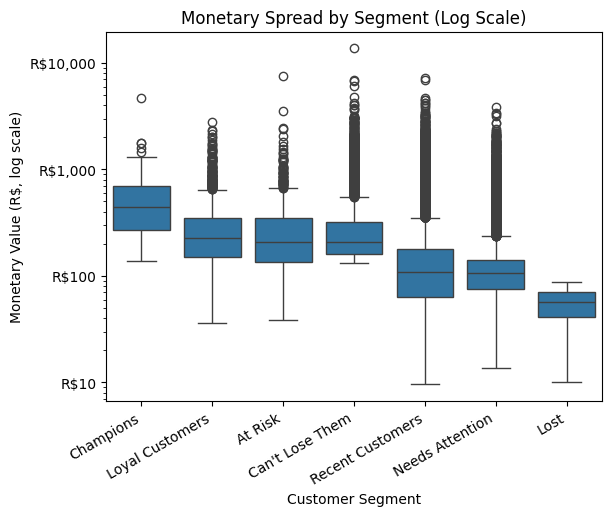

In [ ]:
#Segment Boxplots - Monetary(Log) spread per segment
sns.boxplot(data=df, x='customer_segment', y='monetary',
            order=df.groupby('customer_segment')['monetary'].median().sort_values(ascending=False).index)
plt.yscale('log')
plt.title('Monetary Spread by Segment (Log Scale)')
plt.xlabel('Customer Segment')
plt.ylabel('Monetary Value (R$, log scale)')
plt.gca().yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x):,}'))
plt.xticks(rotation=30, ha='right')
plt.show()

### Key Findings
Monetary value decreases predictably from 'Champions' to 'Lost Customers', validating the segmentation logic. 'Loyal Customers' and 'At Risk' look similar as they both are frequency-driven and not based on spend.
'Can't Lose Them' customers show the highest outlier spend despite inactivity, making them the highest priority win-back target. 'Recent Customers' show low spend consistent with first purchase behaviour, suggesting nurturing campaigns over revenue extraction.

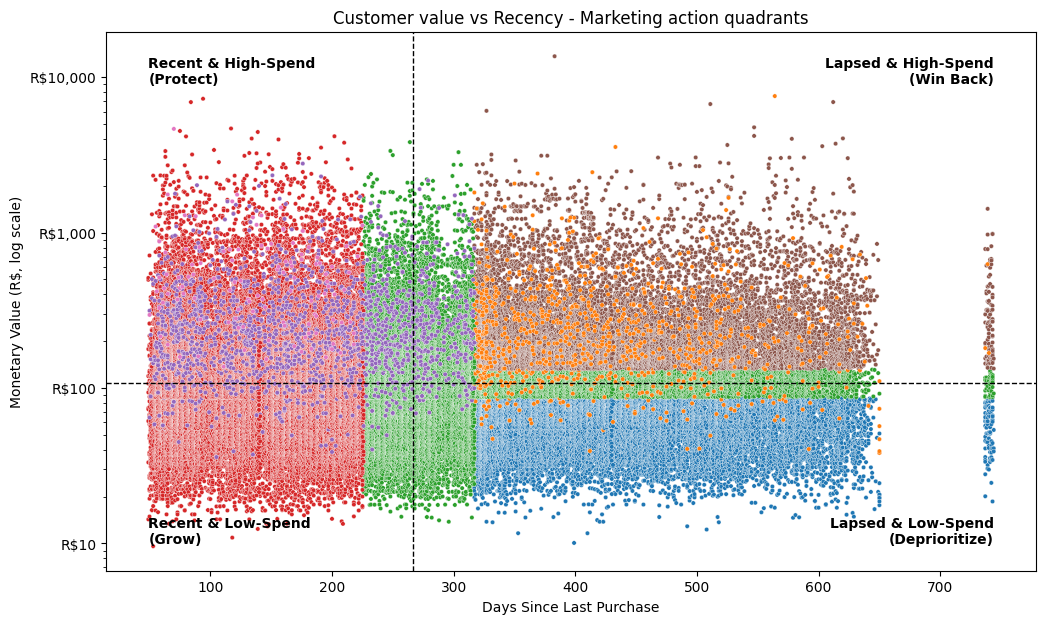

In [ ]:
#Customer value vs recency Quadrant plot
recency_median = df['recency_days'].median()
monetary_median = df['monetary'].median()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='recency_days', y='monetary',
                alpha=1.0, s=10, hue='customer_segment', legend=False)
plt.axvline(recency_median, color='black', linestyle='--', linewidth=1)
plt.axhline(monetary_median, color='black', linestyle='--', linewidth=1)
plt.yscale('log')
plt.title('Customer value vs Recency - Marketing action quadrants')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Monetary Value (R$, log scale)')
plt.gca().yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x):,}'))

plt.text(df['recency_days'].min(), df['monetary'].max(), 'Recent & High-Spend\n(Protect)',
         fontsize=10, ha='left', va='top', fontweight='bold')
plt.text(df['recency_days'].max(), df['monetary'].max(), 'Lapsed & High-Spend\n(Win Back)',
         fontsize=10, ha='right', va='top', fontweight='bold')
plt.text(df['recency_days'].min(), df['monetary'].min(), 'Recent & Low-Spend\n(Grow)',
         fontsize=10, ha='left', va='bottom', fontweight='bold')
plt.text(df['recency_days'].max(), df['monetary'].min(), 'Lapsed & Low-Spend\n(Deprioritize)',
         fontsize=10, ha='right', va='bottom', fontweight='bold')
plt.show()

### Key Findings
The Recency vs Monetary quadrant reveals four distinct customer zones requiring different marketing responses. The 'Win Back' quadrant(lapsed, high-spend) represents the highest value untapped opportunity, customers who demonstrated high spending intent but have disnegaged. A targeted reactivation campaign for this segement offers the highest potential ROI per marketing dollar spent.

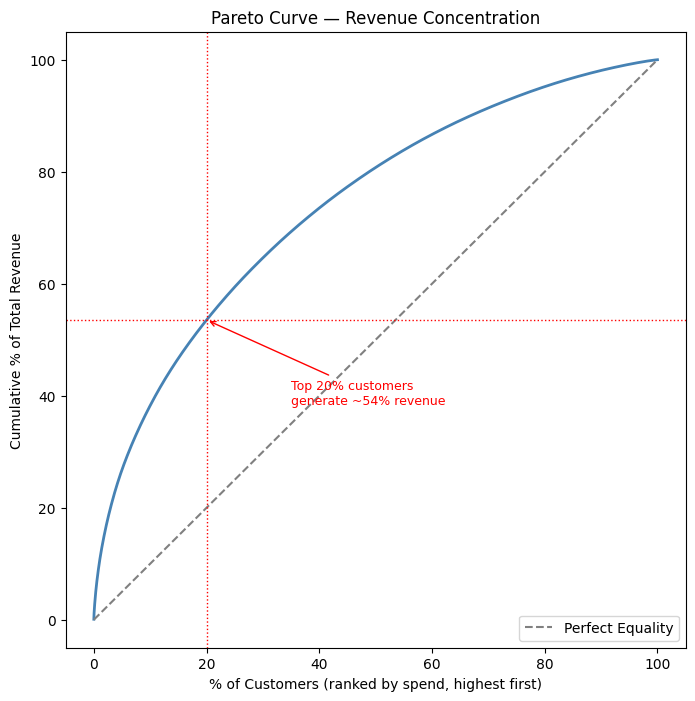

In [ ]:
#Revenue Concentration Analysis - Pareto Curve
df_sorted = df.sort_values('monetary', ascending=False).reset_index(drop=True)
df_sorted['cumulative_revenue'] = df_sorted['monetary'].cumsum()
df_sorted['cumulative_revenue_pct'] = df_sorted['cumulative_revenue'] / df_sorted['monetary'].sum() * 100
df_sorted['customer_pct'] = (df_sorted.index + 1) / len(df_sorted) * 100

plt.figure(figsize=(8, 8))
plt.plot(df_sorted['customer_pct'], df_sorted['cumulative_revenue_pct'], color='steelblue', linewidth=2)
plt.plot([0, 100], [0, 100], color='gray', linestyle='--', label='Perfect Equality')
plt.axvline(20, color='red', linestyle=':', linewidth=1)
plt.axhline(df_sorted[df_sorted['customer_pct'] <= 20]['cumulative_revenue_pct'].max(),
            color='red', linestyle=':', linewidth=1)

top_20_pct_revenue = df_sorted[df_sorted['customer_pct'] <= 20]['cumulative_revenue_pct'].max()
plt.annotate(f'Top 20% customers\ngenerate ~{top_20_pct_revenue:.0f}% revenue',
             xy=(20, top_20_pct_revenue),
             xytext=(35, top_20_pct_revenue - 15),
             fontsize=9,
             color='red',
             arrowprops=dict(arrowstyle='->', color='red'))
plt.title('Pareto Curve — Revenue Concentration')
plt.xlabel('% of Customers (ranked by spend, highest first)')
plt.ylabel('Cumulative % of Total Revenue')
plt.legend()
plt.show()

### Key Findings
Revenue concentration in this dataset is more moderate than the classic 80/20 Pareto principle, the top 20% of customers generate half of the revenue, indicating a broader and mroe evenly distributed customer base rather than extreme dependency on a small elite tier. This is a healthier revenue profile from a risk standpoint because the business isn't overly reliant on a tiny handful of whale customers.

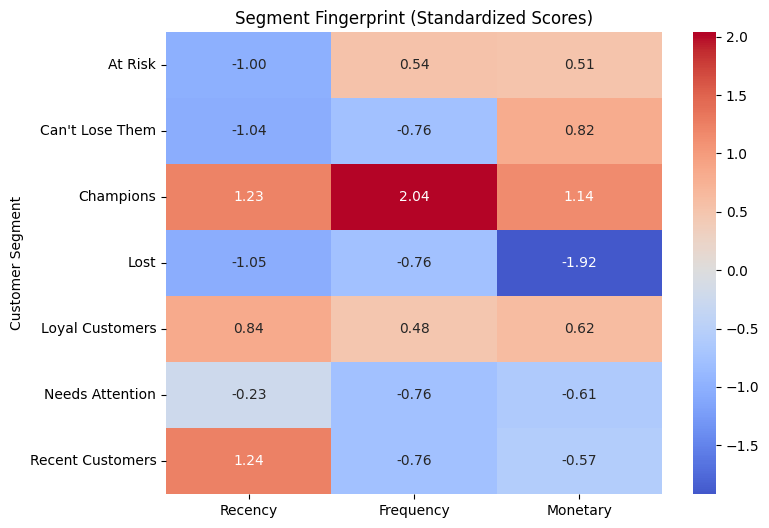

In [ ]:
#Segment Fingerprint Heatmap
from scipy.stats import zscore

segment_profile = df.groupby('customer_segment')[['recency_score', 'frequency_score', 'monetary_score']].mean()
segment_profile_z = segment_profile.apply(zscore)

plt.figure(figsize=(8, 6))
sns.heatmap(segment_profile_z, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            xticklabels=['Recency', 'Frequency', 'Monetary'])
plt.title('Segment Fingerprint (Standardized Scores)')
plt.ylabel('Customer Segment')
plt.show()

### Key Findings
- **Champions** are defined by exceptional repeat frequency (z=+2.04), the most extreme value in the chart
- **Can't Lose Them** show high spend but critical recency lapse,
highest priority win-back segment
- **At Risk** mirrors Loyal Customers in value but recency is declining, urgent retention needed
- **Lost** customers show the lowest monetary score (z=-1.92), minimal marketing ROI